<a href="https://colab.research.google.com/github/marsyandasf/simulasi-sir-er-rgg/blob/main/simulasi_sir_er_vs_rgg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulasi SIR Stokastik pada Graf Erdős–Rényi vs Random Geometric Graph
### Ilustrasi parameter: penyakit mosaik singkong (CMD), penularan antarpetak lewat kutu kebul

**Alur notebook**
1. Setup & parameter
2. Membangkitkan graf ER dan RGG, lalu memverifikasi sifatnya terhadap teori
3. Satu contoh simulasi & kurva epidemi (Monte Carlo)
4. Ukuran akhir wabah vs β: simulasi ER, simulasi RGG, dan rumus teori ER
5. Sweep parameter (analisis sensitivitas): β × ⟨k⟩ × γ
6. Estimasi ambang epidemik numerik & perbandingan dengan rumus ER
7. Visual spasial wabah di RGG

**Model.** Simpul = petak lahan; status S (rentan), I (terinfeksi), R (*removed*: dicabut/dipanen).
Satu langkah = 1 minggu. Tiap langkah, setiap petak I menulari tiap tetangga S dengan peluang β, lalu petak I berpindah ke R dengan peluang γ.
Transmisibilitas per sisi: $T = \dfrac{\beta}{\beta + \gamma - \beta\gamma}$, dan ambang ER: $T\langle k\rangle = 1$.

## 0. Modul simulasi
Sel ini menulis file `sir_graf.py` (isi sama dengan file di repo), sehingga notebook bisa langsung dijalankan di Colab tanpa clone atau upload apa pun.
Cukup pilih **Runtime → Run all**.

In [ ]:
%%writefile sir_graf.py
"""
Simulasi SIR stokastik pada graf Erdős–Rényi (ER) vs Random Geometric Graph (RGG)
dengan ilustrasi parameter penyakit mosaik singkong (CMD).

Simpul = petak lahan, sisi = kemungkinan penularan antarpetak (lewat kutu kebul).
Status simpul: S (rentan), I (terinfeksi), R (removed = dicabut/dipanen).

Satu langkah waktu = 1 minggu. Tiap langkah:
  1. Setiap petak I mencoba menulari setiap tetangga S dengan peluang beta.
  2. Setiap petak I (termasuk yang tertular di langkah sebelumnya, bukan langkah ini)
     berpindah ke R dengan peluang gamma.
Dengan urutan ini, transmisibilitas per sisi adalah
     T = beta / (beta + gamma - beta*gamma)
sehingga ambang epidemik ER (distribusi derajat Poisson) adalah T * <k> = 1.
"""

import math
import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.spatial import cKDTree

# ---------------------------------------------------------------------------
# 1. PARAMETER BIOLOGIS (sumber: Jittamai et al. 2021, Math. Biosci. Eng.)
# ---------------------------------------------------------------------------
DT_HARI = 7                 # 1 langkah = 1 minggu
ROGUING_HARI = 0.03         # laju cabut tanaman sakit, baseline (rentang 0.03-0.1 /hari)
PANEN_HARI = 0.003          # laju panen (/hari)


def laju_ke_peluang(laju_per_hari, dt=DT_HARI):
    """Konversi laju kontinu (/hari) menjadi peluang per langkah: p = 1 - exp(-laju*dt)."""
    return 1.0 - math.exp(-laju_per_hari * dt)


def gamma_dari_roguing(roguing_hari, panen_hari=PANEN_HARI, dt=DT_HARI):
    """Peluang removed per langkah = cabut + panen (dua laju kompetitif dijumlahkan)."""
    return laju_ke_peluang(roguing_hari + panen_hari, dt)


# ---------------------------------------------------------------------------
# 2. PEMBANGKIT GRAF
# ---------------------------------------------------------------------------
def graf_er(N, k_rata, rng):
    """G(N,p) dengan p = <k>/(N-1). Mengembalikan matriks adjacency CSR."""
    p = k_rata / (N - 1)
    G = nx.fast_gnp_random_graph(N, p, seed=int(rng.integers(2**31)))
    return nx.to_scipy_sparse_array(G, format="csr", dtype=np.int8), None


def graf_rgg(N, k_rata, rng, torus=True):
    """
    RGG: N titik acak seragam di [0,1]^2, dua titik terhubung jika jaraknya < r.
    Dengan batas periodik (torus), <k> = (N-1)*pi*r^2 sehingga r = sqrt(<k>/(pi*(N-1))).
    Mengembalikan (adjacency CSR, posisi titik).
    """
    r = math.sqrt(k_rata / (math.pi * (N - 1)))
    pos = rng.random((N, 2))
    tree = cKDTree(pos, boxsize=1.0 if torus else None)
    pasangan = tree.query_pairs(r, output_type="ndarray")
    i, j = pasangan[:, 0], pasangan[:, 1]
    data = np.ones(2 * len(i), dtype=np.int8)
    A = sp.csr_array((data, (np.r_[i, j], np.r_[j, i])), shape=(N, N))
    return A, pos


PEMBANGKIT = {"ER": graf_er, "RGG": graf_rgg}


# ---------------------------------------------------------------------------
# 3. SIMULASI SIR STOKASTIK WAKTU DISKRIT
# ---------------------------------------------------------------------------
S, I, R = 0, 1, 2


def simulasi_sir(A, beta, gamma, rng, n_awal=None, frac_awal=0.01, t_maks=2000,
                 simpan_status_akhir=False):
    """
    Satu realisasi SIR pada graf dengan adjacency CSR A.
    Mengembalikan dict berisi deret waktu S(t), I(t), R(t) (dalam proporsi).
    """
    N = A.shape[0]
    indptr, indices = A.indptr, A.indices
    status = np.zeros(N, dtype=np.int8)
    n0 = n_awal if n_awal is not None else max(1, int(round(frac_awal * N)))
    status[rng.choice(N, n0, replace=False)] = I

    riwayat = [(N - n0, n0, 0)]
    for _ in range(t_maks):
        terinfeksi = np.flatnonzero(status == I)
        if terinfeksi.size == 0:
            break
        # --- transmisi: kumpulkan semua tetangga dari simpul terinfeksi ---
        awal, akhir = indptr[terinfeksi], indptr[terinfeksi + 1]
        panjang = akhir - awal
        if panjang.sum() > 0:
            idx = np.repeat(awal - np.cumsum(np.r_[0, panjang[:-1]]), panjang) + np.arange(panjang.sum())
            tetangga = indices[idx]
            # m_j = banyaknya tetangga terinfeksi dari simpul j
            m = np.bincount(tetangga, minlength=N)
            kandidat = np.flatnonzero((m > 0) & (status == S))
            # peluang tertular = 1 - (1-beta)^m  (percobaan independen per sisi)
            p_tular = 1.0 - (1.0 - beta) ** m[kandidat]
            baru = kandidat[rng.random(kandidat.size) < p_tular]
        else:
            baru = np.empty(0, dtype=int)
        # --- removal: hanya simpul yang sudah I sebelum langkah ini ---
        sembuh = terinfeksi[rng.random(terinfeksi.size) < gamma]
        status[sembuh] = R
        status[baru] = I
        riwayat.append(np.bincount(status, minlength=3))

    riwayat = np.asarray(riwayat, dtype=float) / N
    hasil = {"S": riwayat[:, 0], "I": riwayat[:, 1], "R": riwayat[:, 2]}
    hasil["ukuran_akhir"] = hasil["R"][-1] + hasil["I"][-1]
    hasil["puncak_I"] = hasil["I"].max()
    hasil["waktu_puncak"] = int(hasil["I"].argmax())
    hasil["durasi"] = len(hasil["I"]) - 1
    if simpan_status_akhir:
        hasil["status"] = status
    return hasil


# ---------------------------------------------------------------------------
# 4. TEORI ER (pembanding analitik)
# ---------------------------------------------------------------------------
def transmisibilitas(beta, gamma):
    return beta / (beta + gamma - beta * gamma)


def beta_kritis_er(k_rata, gamma):
    """Solusi T*<k> = 1  ->  beta_c = gamma / (<k> - 1 + gamma)."""
    return gamma / (k_rata - 1 + gamma)


def ukuran_akhir_teori_er(beta, gamma, k_rata, iterasi=500):
    """
    Ukuran wabah besar di ER (limit N besar) lewat perkolasi ikatan:
    s = 1 - exp(-T <k> s). Diselesaikan dengan iterasi titik tetap.
    """
    Tk = transmisibilitas(beta, gamma) * k_rata
    if Tk <= 1:
        return 0.0
    s = 0.5
    for _ in range(iterasi):
        s = 1.0 - math.exp(-Tk * s)
    return s


# ---------------------------------------------------------------------------
# 5. MONTE CARLO
# ---------------------------------------------------------------------------
def monte_carlo(nama_graf, N, k_rata, beta, gamma, M, rng, graf_baru_tiap_ulangan=True,
                simpan_kurva=False, **kw):
    """
    Ulangi simulasi M kali. Graf dibangkitkan ulang tiap ulangan (rata-rata atas
    ensembel graf, bukan hanya satu graf). Mengembalikan ringkasan statistik.
    """
    buat = PEMBANGKIT[nama_graf]
    A, _ = buat(N, k_rata, rng)
    ukuran, puncak, waktu_puncak, kurva = [], [], [], []
    for m in range(M):
        if graf_baru_tiap_ulangan and m > 0:
            A, _ = buat(N, k_rata, rng)
        h = simulasi_sir(A, beta, gamma, rng, **kw)
        ukuran.append(h["ukuran_akhir"])
        puncak.append(h["puncak_I"])
        waktu_puncak.append(h["waktu_puncak"])
        if simpan_kurva:
            kurva.append(h["I"])
    ukuran = np.asarray(ukuran)
    ringkas = {
        "graf": nama_graf, "N": N, "k": k_rata, "beta": beta, "gamma": gamma,
        "T": transmisibilitas(beta, gamma),
        "ukuran_akhir_rata": ukuran.mean(),
        "ukuran_akhir_sd": ukuran.std(ddof=1),
        "peluang_wabah_besar": (ukuran > 0.10).mean(),   # definisi 'wabah besar' > 10% petak
        "puncak_I_rata": np.mean(puncak),
        "waktu_puncak_rata": np.mean(waktu_puncak),
    }
    if simpan_kurva:
        ringkas["kurva_I"] = kurva
    return ringkas


def estimasi_beta_kritis(beta_grid, nilai, batas=0.10):
    """
    Estimasi numerik ambang: beta terkecil di mana rata-rata ukuran akhir melewati `batas`,
    diinterpolasi linear pada skala log beta. Mengembalikan nan jika tidak pernah melewati.
    """
    beta_grid, nilai = np.asarray(beta_grid), np.asarray(nilai)
    atas = np.flatnonzero(nilai >= batas)
    if atas.size == 0 or atas[0] == 0:
        return float("nan")
    j = atas[0]
    x0, x1 = math.log(beta_grid[j - 1]), math.log(beta_grid[j])
    y0, y1 = nilai[j - 1], nilai[j]
    return math.exp(x0 + (batas - y0) * (x1 - x0) / (y1 - y0))

Writing sir_graf.py


In [ ]:
import os
os.makedirs("hasil", exist_ok=True)   # semua gambar & CSV disimpan ke folder hasil/
import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt, math, time
from sir_graf import *

WARNA = {"ER": "#2a78d6", "RGG": "#eb6834", "teori": "#52514e"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b5b4ae", "axes.labelcolor": "#0b0b0b", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False,
})
SEED = 2026
rng = np.random.default_rng(SEED)

# catat versi library (tulis di Bab 3 / requirements.txt)
import scipy, matplotlib, sys
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| scipy", scipy.__version__,
      "| networkx", nx.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

Python 3.13.15 | numpy 2.1.3 | scipy 1.16.3 | networkx 3.6.1 | pandas 2.2.3 | matplotlib 3.10.0


## 1. Parameter

| Simbol | Arti | Nilai | Sumber |
|---|---|---|---|
| N | jumlah petak | 1000 | asumsi |
| ⟨k⟩ | rata-rata tetangga per petak | 4, 8, 12 | asumsi (kerapatan tanam) |
| roguing | laju cabut tanaman sakit | 0 / 0,03 / 0,1 per hari | Jittamai et al. (2021) |
| panen | laju panen | 0,003 per hari | Jittamai et al. (2021) |
| γ | peluang *removed* per minggu | $1-e^{-(\text{roguing}+\text{panen})\cdot 7}$ | konversi |
| β | peluang tular per sisi per minggu | di-*sweep* 0,001–0,5 (20 nilai) | tidak tersedia langsung di literatur |
| I₀ | petak terinfeksi awal | 1% petak | asumsi |

In [ ]:
N = 1000
K_BASE = 8
GAMMA_BASE = gamma_dari_roguing(ROGUING_HARI)          # roguing 0.03/hari + panen
print(f"gamma baseline per minggu = {GAMMA_BASE:.4f}")
print(f"beta kritis teori ER (<k>={K_BASE}) = {beta_kritis_er(K_BASE, GAMMA_BASE):.4f}")

gamma baseline per minggu = 0.2063
beta kritis teori ER (<k>=8) = 0.0286


## 2. Membangkitkan graf & verifikasi sifatnya

Yang dicek: rata-rata derajat, variansi derajat (Poisson → variansi ≈ rata-rata), koefisien clustering
(teori: ER ≈ p ≈ ⟨k⟩/N; RGG 2D ≈ $1 - \tfrac{3\sqrt3}{4\pi} \approx 0{,}5865$), dan ukuran komponen terbesar.

In [ ]:
baris = []
for nama in ["ER", "RGG"]:
    for k in [4, 8, 12]:
        A, _ = PEMBANGKIT[nama](N, k, rng)
        G = nx.from_scipy_sparse_array(A)
        d = np.array([x for _, x in G.degree()])
        baris.append({"graf": nama, "k target": k, "<k>": d.mean(), "var(k)": d.var(),
                      "clustering": nx.average_clustering(G),
                      "komponen terbesar (%)": 100 * max(len(c) for c in nx.connected_components(G)) / N})
tabel_graf = pd.DataFrame(baris)
print("Clustering teori RGG 2D =", round(1 - 3 * math.sqrt(3) / (4 * math.pi), 4))
tabel_graf.round(3)

Clustering teori RGG 2D = 0.5865


,graf,k target,<k>,var(k),clustering,komponen terbesar (%)
0,ER,4,3.996,4.036,0.005,98.2
1,ER,8,8.092,8.568,0.007,99.9
2,ER,12,12.020,12.868,0.012,100.0
3,RGG,4,4.192,4.335,0.550,39.0
4,RGG,8,7.892,7.544,0.573,99.8
5,RGG,12,12.066,11.564,0.585,100.0


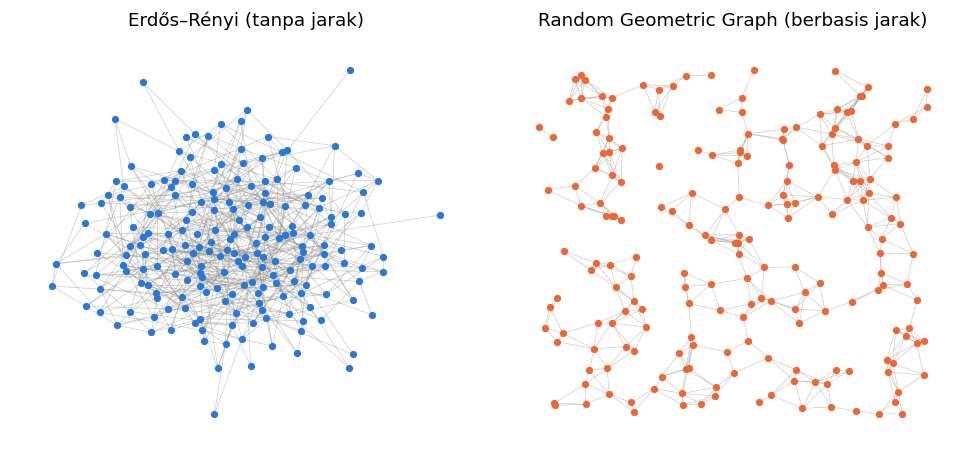

In [ ]:
# Gambar contoh graf kecil (N=200) supaya strukturnya terlihat
fig, ax = plt.subplots(1, 2, figsize=(9, 4.3))
r_small = np.random.default_rng(7)
A_er, _ = graf_er(200, 6, r_small)
A_rg, pos = graf_rgg(200, 6, r_small, torus=False)
for a, (A, judul, p) in zip(ax, [(A_er, "Erdős–Rényi (tanpa jarak)", None),
                                 (A_rg, "Random Geometric Graph (berbasis jarak)", pos)]):
    G = nx.from_scipy_sparse_array(A)
    lay = nx.spring_layout(G, seed=1) if p is None else {i: p[i] for i in range(len(p))}
    nx.draw_networkx_edges(G, lay, ax=a, width=0.5, alpha=0.4, edge_color="#8a8983")
    nx.draw_networkx_nodes(G, lay, ax=a, node_size=14,
                           node_color=WARNA["ER"] if p is None else WARNA["RGG"])
    a.set_title(judul); a.set_axis_off()
plt.tight_layout(); plt.savefig("hasil/fig1_contoh_graf.png", dpi=200, bbox_inches="tight"); plt.show()

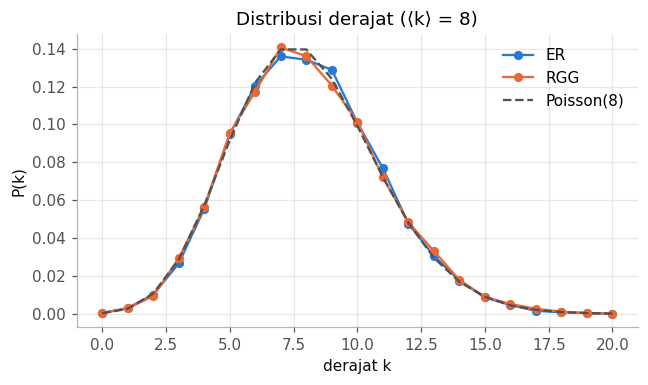

In [ ]:
# Distribusi derajat: keduanya Poisson -> perbedaan hasil nanti berasal dari geometri (clustering)
from scipy.stats import poisson
fig, ax = plt.subplots(figsize=(6, 3.6))
kk = np.arange(0, 21)
for nama in ["ER", "RGG"]:
    deg = []
    for _ in range(20):
        A, _ = PEMBANGKIT[nama](N, K_BASE, rng)
        deg.append(np.asarray(A.sum(axis=1)).ravel())
    deg = np.concatenate(deg)
    frek = np.bincount(deg, minlength=21)[:21] / deg.size
    ax.plot(kk, frek, "o-", color=WARNA[nama], ms=5, lw=1.5, label=nama)
ax.plot(kk, poisson.pmf(kk, K_BASE), "--", color=WARNA["teori"], lw=1.5, label=f"Poisson({K_BASE})")
ax.set_xlabel("derajat k"); ax.set_ylabel("P(k)"); ax.set_title("Distribusi derajat (⟨k⟩ = 8)")
ax.legend(); plt.tight_layout(); plt.savefig("hasil/fig2_distribusi_derajat.png", dpi=200, bbox_inches="tight"); plt.show()

## 3. Kurva epidemi (Monte Carlo)
β = 0,08, ⟨k⟩ = 8, γ baseline. Garis = rata-rata, pita = persentil 10–90 dari M ulangan.

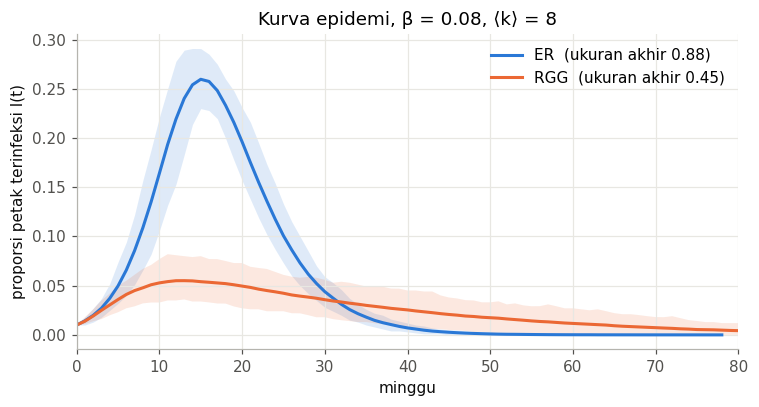

In [ ]:
BETA_CONTOH, M_KURVA = 0.08, 200
fig, ax = plt.subplots(figsize=(7, 3.8))
for nama in ["ER", "RGG"]:
    h = monte_carlo(nama, N, K_BASE, BETA_CONTOH, GAMMA_BASE, M_KURVA, rng, simpan_kurva=True)
    L = max(len(c) for c in h["kurva_I"])
    mat = np.array([np.pad(c, (0, L - len(c))) for c in h["kurva_I"]])   # setelah padam, I = 0
    t = np.arange(L)
    ax.fill_between(t, np.percentile(mat, 10, 0), np.percentile(mat, 90, 0), color=WARNA[nama], alpha=0.15, lw=0)
    ax.plot(t, mat.mean(0), color=WARNA[nama], label=f"{nama}  (ukuran akhir {h['ukuran_akhir_rata']:.2f})")
ax.set_xlim(0, 80); ax.set_xlabel("minggu"); ax.set_ylabel("proporsi petak terinfeksi I(t)")
ax.set_title(f"Kurva epidemi, β = {BETA_CONTOH}, ⟨k⟩ = {K_BASE}")
ax.legend(); plt.tight_layout(); plt.savefig("hasil/fig3_kurva_epidemi.png", dpi=200, bbox_inches="tight"); plt.show()

## 4. Ukuran akhir wabah vs β
Titik = simulasi; garis putus-putus = solusi teori ER $s = 1 - e^{-T\langle k\rangle s}$.
Kalau simulasi ER menempel ke garis teori, kode sudah benar. Jarak antara kurva RGG dan teori ER = bias akibat mengabaikan jarak.

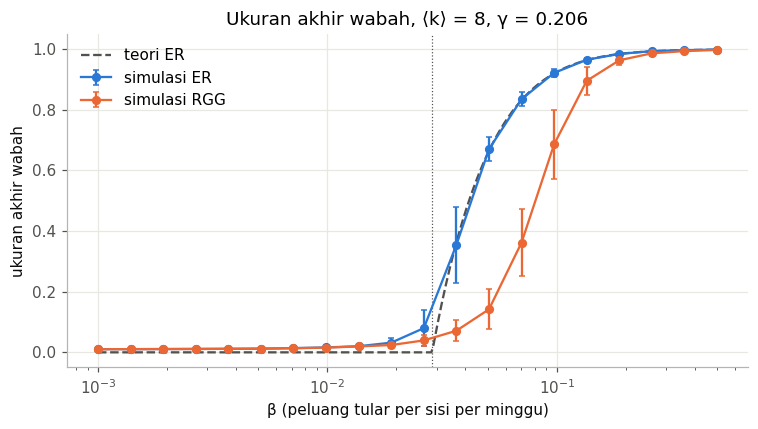

In [ ]:
BETA_GRID = np.geomspace(0.001, 0.5, 20)
M_SWEEP = 100          # naikkan ke 200 untuk hasil final skripsi
hasil_b = []
for nama in ["ER", "RGG"]:
    for b in BETA_GRID:
        hasil_b.append(monte_carlo(nama, N, K_BASE, b, GAMMA_BASE, M_SWEEP, rng))
df_b = pd.DataFrame(hasil_b)

fig, ax = plt.subplots(figsize=(7, 4))
bb = np.geomspace(0.001, 0.5, 300)
ax.plot(bb, [ukuran_akhir_teori_er(x, GAMMA_BASE, K_BASE) for x in bb], "--", color=WARNA["teori"], lw=1.5,
        label="teori ER")
for nama in ["ER", "RGG"]:
    d = df_b[df_b.graf == nama]
    ax.errorbar(d.beta, d.ukuran_akhir_rata, yerr=d.ukuran_akhir_sd, fmt="o-", ms=5, lw=1.5, capsize=2,
                color=WARNA[nama], label=f"simulasi {nama}")
ax.axvline(beta_kritis_er(K_BASE, GAMMA_BASE), color=WARNA["teori"], lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_xlabel("β (peluang tular per sisi per minggu)"); ax.set_ylabel("ukuran akhir wabah")
ax.set_title(f"Ukuran akhir wabah, ⟨k⟩ = {K_BASE}, γ = {GAMMA_BASE:.3f}")
ax.legend(); plt.tight_layout(); plt.savefig("hasil/fig4_ukuran_akhir_vs_beta.png", dpi=200, bbox_inches="tight"); plt.show()

## 5. Sweep parameter (analisis sensitivitas)
2 graf × 20 β × 3 ⟨k⟩ × 3 γ = 360 kombinasi, masing-masing M ulangan (graf dibangkitkan ulang tiap ulangan).
Dengan M = 100 butuh sekitar 8–10 menit di laptop biasa. Hasil disimpan ke `hasil_sweep.csv`.

In [ ]:
K_LIST = [4, 8, 12]
ROGUING_LIST = {"tanpa roguing": 0.0, "roguing baseline": 0.03, "roguing intensif": 0.10}
t0, hasil = time.time(), []
for label_g, rog in ROGUING_LIST.items():
    g = gamma_dari_roguing(rog)
    for k in K_LIST:
        for nama in ["ER", "RGG"]:
            for b in BETA_GRID:
                r = monte_carlo(nama, N, k, b, g, M_SWEEP, rng)
                r["skenario_gamma"] = label_g
                hasil.append(r)
df = pd.DataFrame(hasil)
df.to_csv("hasil/hasil_sweep.csv", index=False)
print(f"selesai: {len(df)} kombinasi dalam {time.time() - t0:.0f} detik")
df.head()

selesai: 360 kombinasi dalam 835 detik


,graf,N,k,beta,gamma,T,ukuran_akhir_rata,ukuran_akhir_sd,peluang_wabah_besar,puncak_I_rata,waktu_puncak_rata,skenario_gamma
0,ER,1000,4,0.001000,0.020781,0.045955,0.01252,0.002338,0.0,0.01027,2.16,tanpa roguing
1,ER,1000,4,0.001387,0.020781,0.062646,0.01314,0.002234,0.0,0.01027,2.01,tanpa roguing
2,ER,1000,4,0.001924,0.020781,0.084870,0.01523,0.003387,0.0,0.01058,4.21,tanpa roguing
3,ER,1000,4,0.002668,0.020781,0.114041,0.01791,0.005164,0.0,0.01085,9.05,tanpa roguing
4,ER,1000,4,0.003700,0.020781,0.151614,0.02323,0.010261,0.0,0.01184,14.50,tanpa roguing


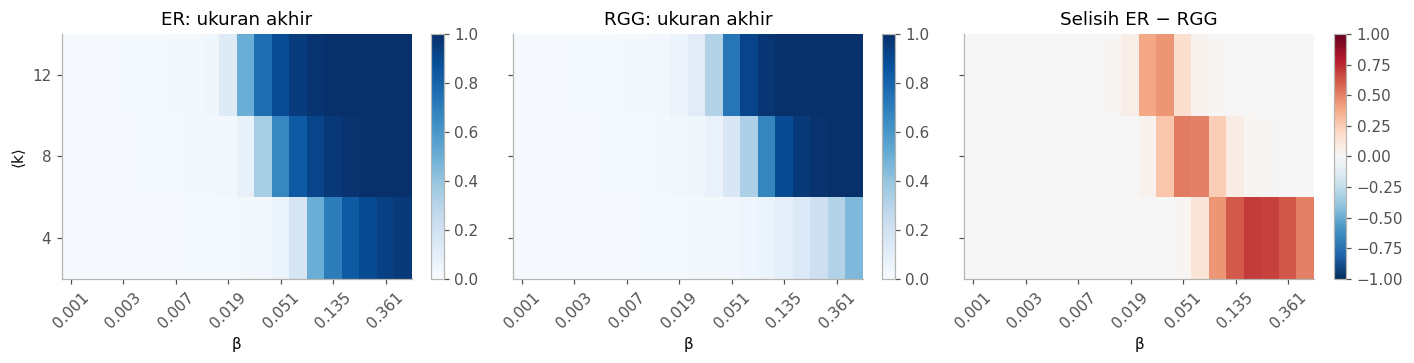

In [ ]:
# Heatmap ukuran akhir: baris = <k>, kolom = beta, untuk gamma baseline
from matplotlib.colors import TwoSlopeNorm
d0 = df[df.skenario_gamma == "roguing baseline"]
piv = {n: d0[d0.graf == n].pivot(index="k", columns="beta", values="ukuran_akhir_rata") for n in ["ER", "RGG"]}
selisih = piv["ER"] - piv["RGG"]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
lab_b = [f"{x:.3f}" for x in BETA_GRID]
for a, (judul, M, cmap, norm) in zip(ax, [
        ("ER: ukuran akhir", piv["ER"], "Blues", None),
        ("RGG: ukuran akhir", piv["RGG"], "Blues", None),
        ("Selisih ER − RGG", selisih, "RdBu_r", TwoSlopeNorm(0, -1, 1))]):
    im = a.imshow(M.values, aspect="auto", origin="lower", cmap=cmap, norm=norm,
                  vmin=None if norm else 0, vmax=None if norm else 1)
    a.set_xticks(range(0, len(BETA_GRID), 3)); a.set_xticklabels(lab_b[::3], rotation=45)
    a.set_yticks(range(len(K_LIST))); a.set_yticklabels(K_LIST)
    a.set_title(judul); a.set_xlabel("β"); a.grid(False)
    fig.colorbar(im, ax=a, fraction=0.046)
ax[0].set_ylabel("⟨k⟩")
plt.tight_layout(); plt.savefig("hasil/fig5_heatmap.png", dpi=200, bbox_inches="tight"); plt.show()

## 6. Ambang epidemik: teori ER vs estimasi numerik
Ambang numerik = β terkecil di mana rata-rata ukuran akhir > 10% (interpolasi pada skala log).
Kolom `rasio RGG/ER` > 1 berarti graf spasial butuh β lebih besar agar wabah meluas.

In [ ]:
baris = []
for label_g, rog in ROGUING_LIST.items():
    g = gamma_dari_roguing(rog)
    for k in K_LIST:
        sub = df[(df.skenario_gamma == label_g) & (df.k == k)]
        est = {n: estimasi_beta_kritis(sub[sub.graf == n].beta, sub[sub.graf == n].ukuran_akhir_rata)
               for n in ["ER", "RGG"]}
        baris.append({"skenario": label_g, "gamma": round(g, 4), "<k>": k,
                      "beta_c teori ER": beta_kritis_er(k, g),
                      "beta_c simulasi ER": est["ER"], "beta_c simulasi RGG": est["RGG"],
                      "rasio RGG/ER": est["RGG"] / est["ER"]})
tabel_ambang = pd.DataFrame(baris)
tabel_ambang.to_csv("hasil/tabel_ambang.csv", index=False)
tabel_ambang.round(4)

,skenario,gamma,<k>,beta_c teori ER,beta_c simulasi ER,beta_c simulasi RGG,rasio RGG/ER
0,tanpa roguing,0.0208,4,0.0069,0.0063,0.0171,2.7301
1,tanpa roguing,0.0208,8,0.0030,0.0028,0.0045,1.6341
2,tanpa roguing,0.0208,12,0.0019,0.0019,0.0026,1.3941
3,roguing baseline,0.2063,4,0.0643,0.0580,0.1480,2.5511
4,roguing baseline,0.2063,8,0.0286,0.0272,0.0415,1.5265
5,roguing baseline,0.2063,12,0.0184,0.0173,0.0245,1.4121
6,roguing intensif,0.5137,4,0.1462,0.1396,0.2836,2.0311
7,roguing intensif,0.5137,8,0.0684,0.0628,0.0950,1.5120
8,roguing intensif,0.5137,12,0.0446,0.0400,0.0546,1.3645


Catatan membaca tabel:
- Pada ⟨k⟩ = 4, RGG berada di sekitar ambang perkolasi kontinum (⟨k⟩ ≈ 4,5): komponen terbesarnya hanya sekitar 40% petak (lihat tabel di bagian 2), jadi wabah di RGG terbendung oleh struktur graf itu sendiri, bukan hanya oleh β.
- `NaN` berarti ukuran akhir tidak pernah melewati 10% di rentang β yang diuji (atau sudah melewati sejak β terkecil).

## 7. Visual spasial wabah di RGG
Satu realisasi: warna menunjukkan status akhir petak. Terlihat wabah menyebar sebagai "gumpalan" dari titik awal, bukan acak.

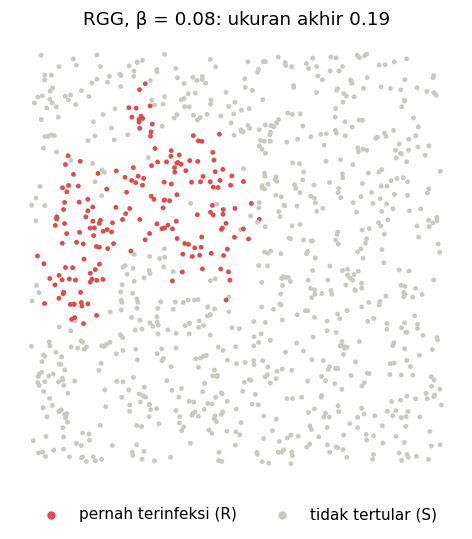

In [ ]:
r_vis = np.random.default_rng(11)
A, pos = graf_rgg(N, K_BASE, r_vis)
B_VIS = 0.08
h = simulasi_sir(A, B_VIS, GAMMA_BASE, r_vis, n_awal=3, simpan_status_akhir=True)
fig, ax = plt.subplots(figsize=(5, 5))
warna_status = np.where(h["status"] != S, "#e34948", "#c9c8c2")
ax.scatter(pos[:, 0], pos[:, 1], s=10, c=warna_status, lw=0)
ax.scatter([], [], c="#e34948", s=20, label="pernah terinfeksi (R)")
ax.scatter([], [], c="#c9c8c2", s=20, label="tidak tertular (S)")
ax.set_title(f"RGG, β = {B_VIS}: ukuran akhir {h['ukuran_akhir']:.2f}"); ax.set_aspect("equal")
ax.set_axis_off(); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.tight_layout(); plt.savefig("hasil/fig6_spasial_rgg.png", dpi=200, bbox_inches="tight"); plt.show()

## 8. Unduh semua hasil (khusus Colab)
Mengemas folder `hasil/` jadi `hasil.zip` lalu mengunduhnya. Upload isinya ke folder `hasil/` di repo GitHub
(**Add file → Upload files**) dengan pesan commit yang jelas, misalnya `hasil run final M=200`.

In [1]:
import shutil, sys
shutil.make_archive("hasil", "zip", "hasil")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("hasil.zip")
else:
    print("hasil.zip dibuat di folder ini")

FileNotFoundError: [Errno 2] No such file or directory: 'hasil'